<a href="https://colab.research.google.com/github/AnastasiaKovalenko232/iad-practices/blob/main/practice-5/5_7_SVM_Rbf_Kernel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

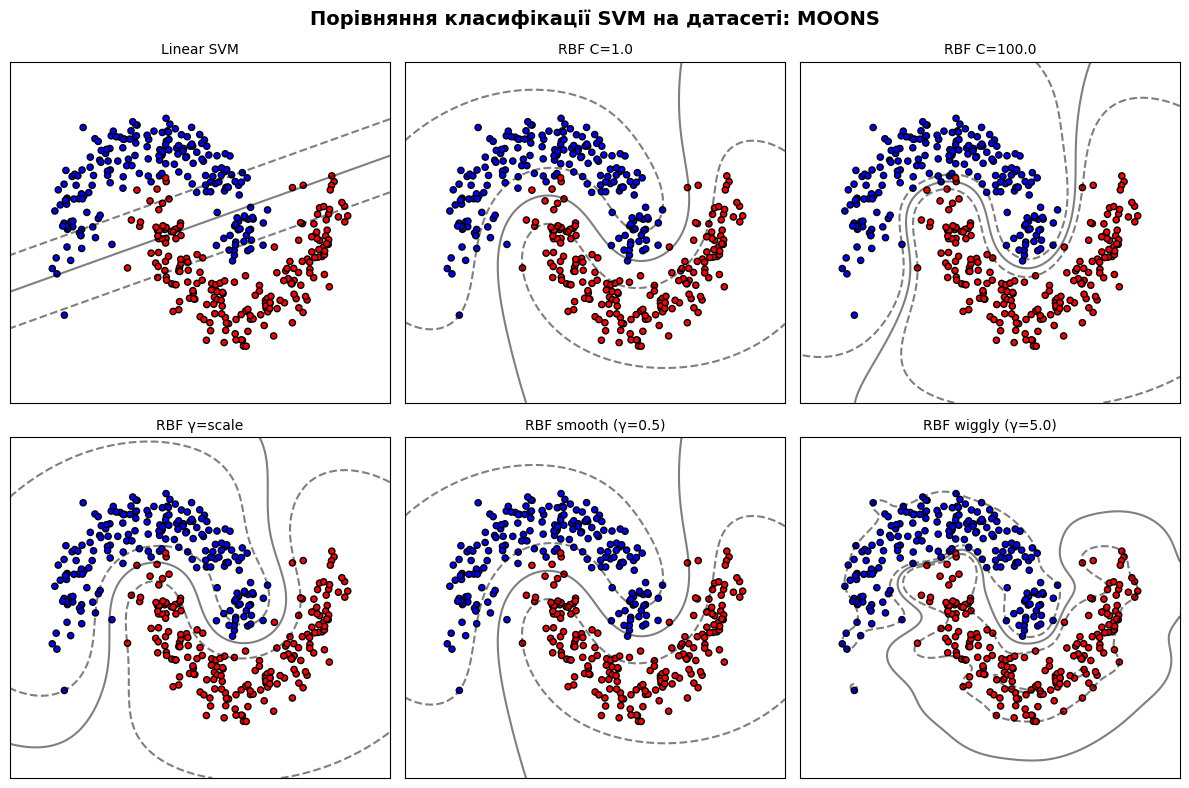

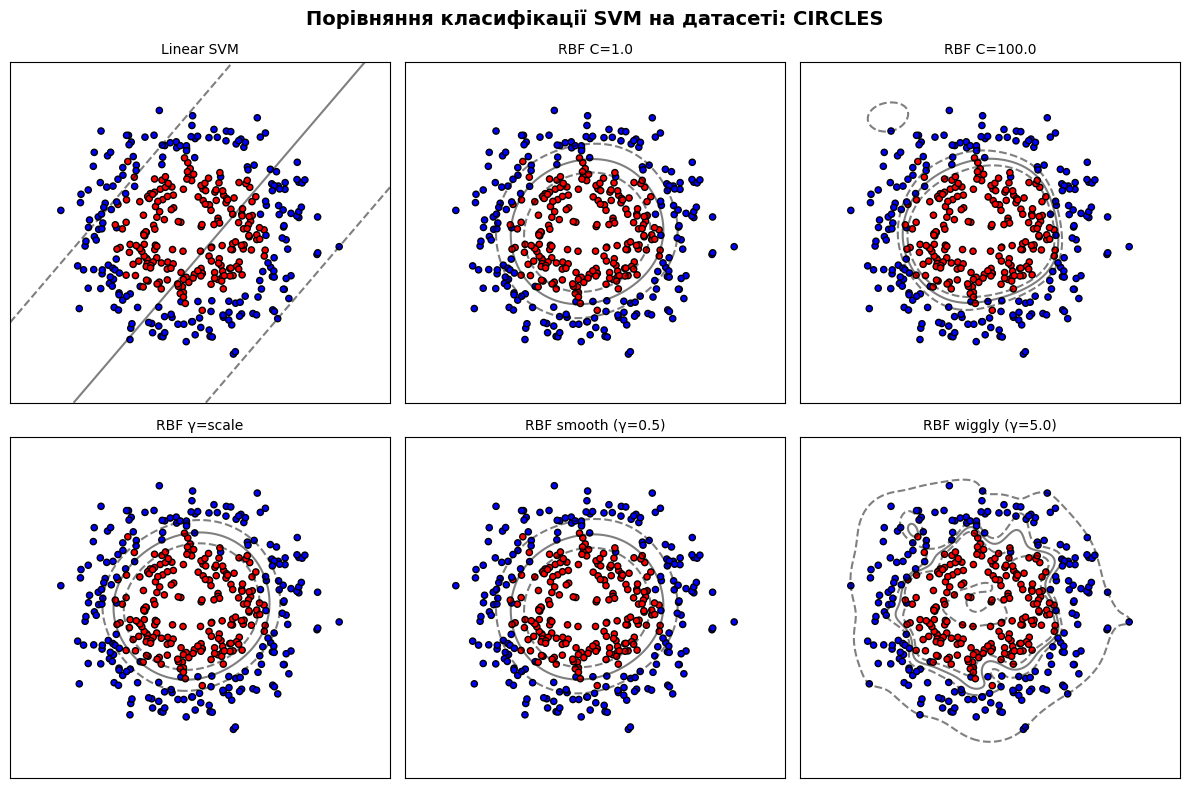

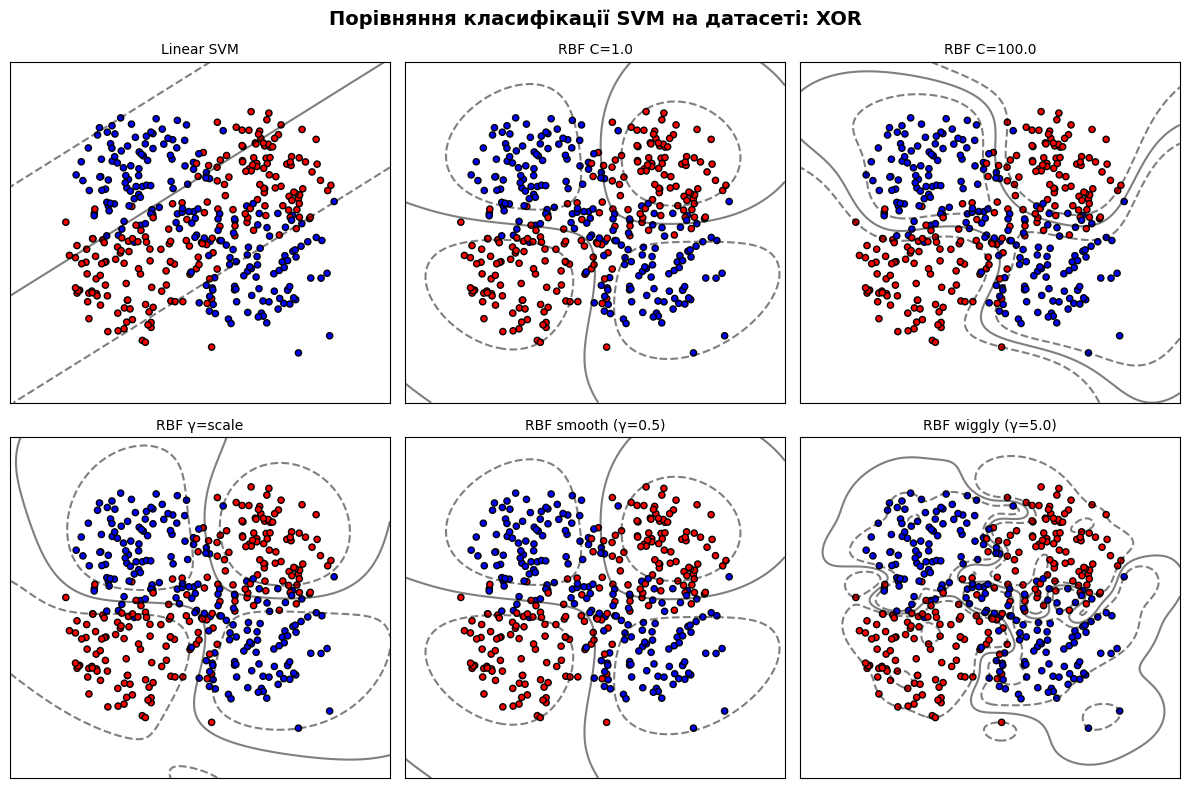

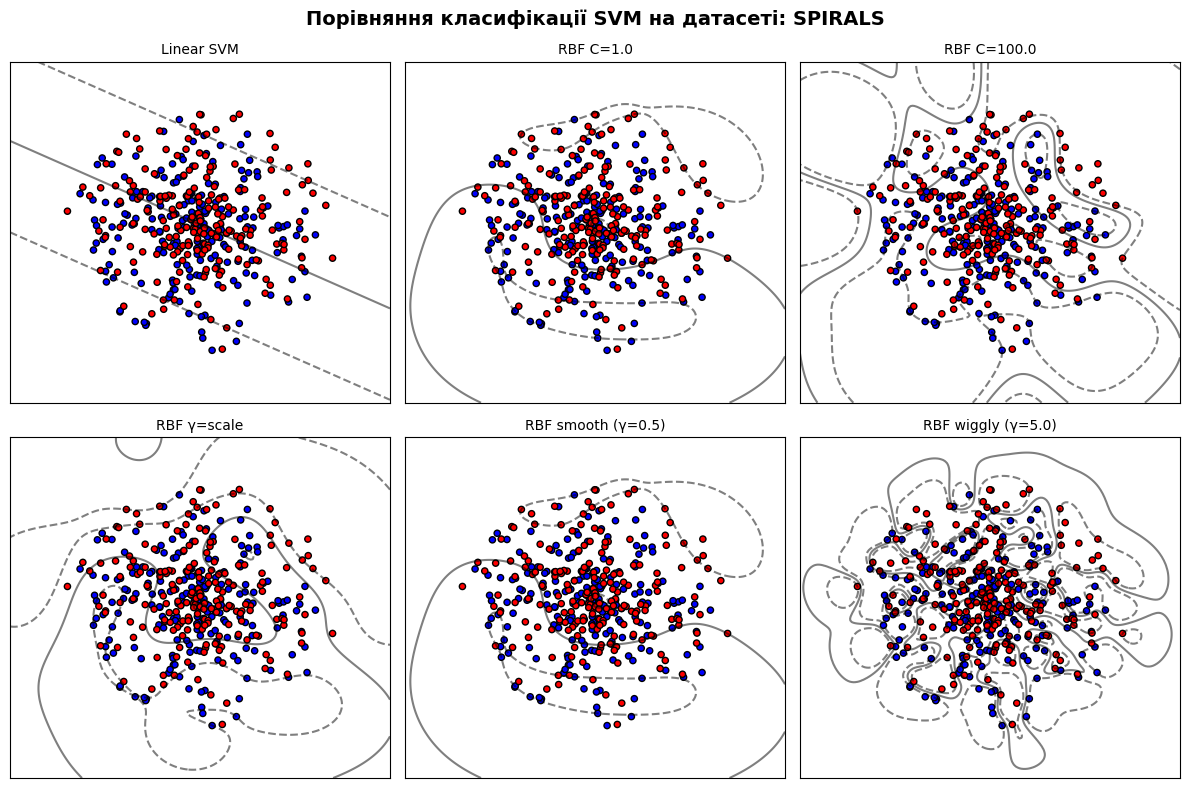

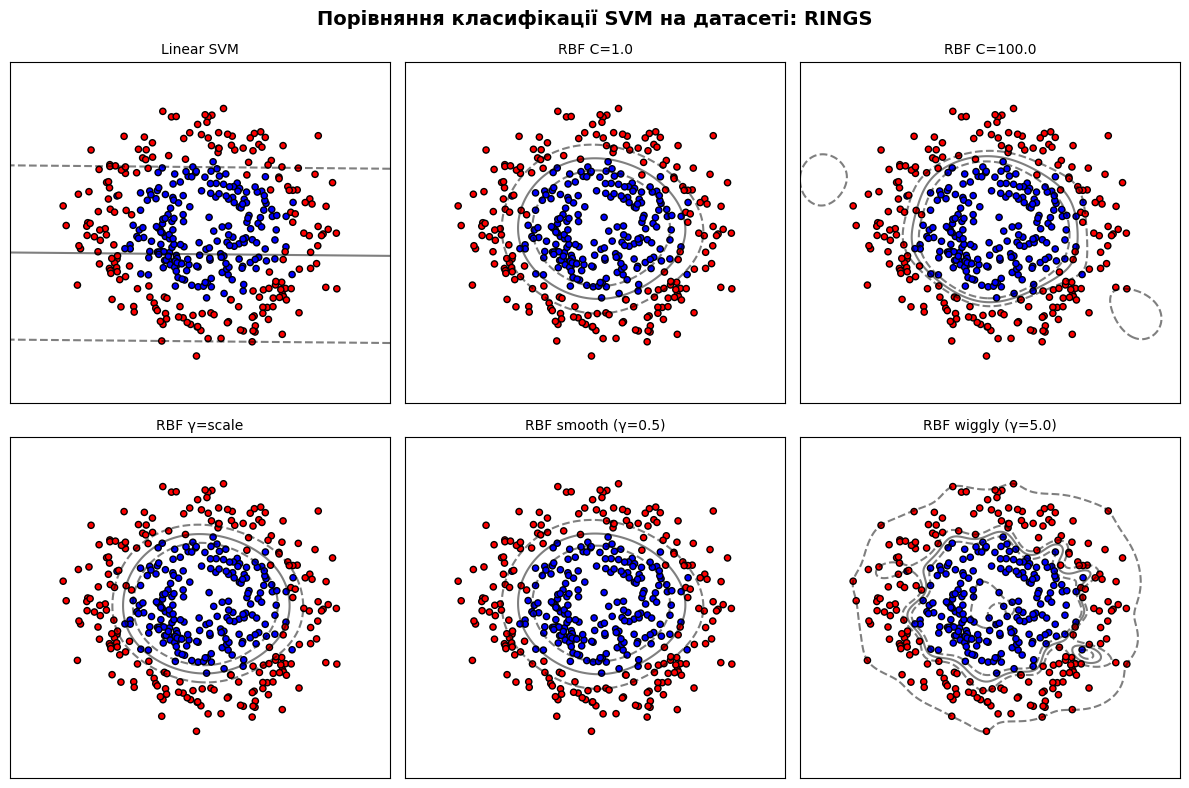

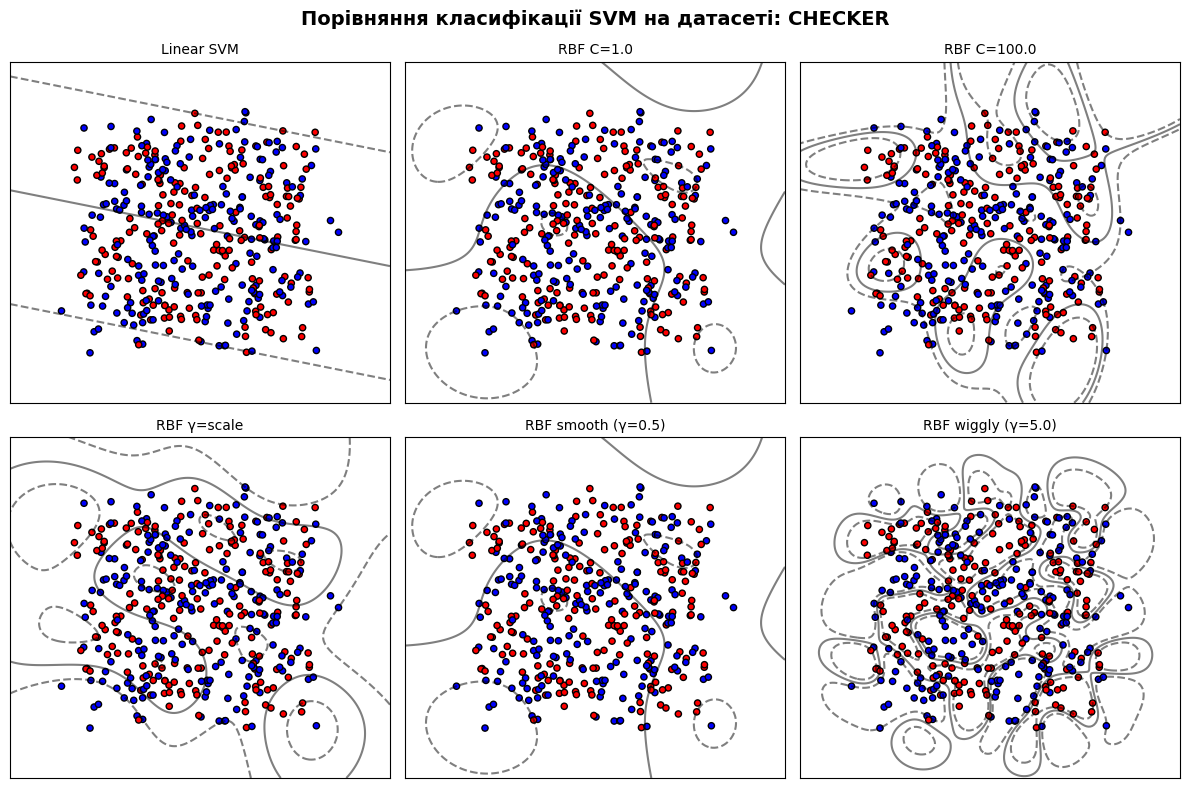

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons, make_circles

# === 1. ВБУДОВАНА ФУНКЦІЯ ГЕНЕРАЦІЇ ДАТАСЕТІВ (Заміна файлу datasets_generation.py) ===
def load_dataset(name, n=600, noise=0.2, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    if name == "moons":
        return make_moons(n_samples=n, noise=noise, random_state=42)
    elif name == "circles":
        return make_circles(n_samples=n, noise=noise, factor=0.5, random_state=42)
    elif name == "xor":
        X = rng.uniform(-1, 1, size=(n, 2))
        y = (X[:, 0] * X[:, 1] > 0).astype(int)
        X += rng.normal(0, noise, size=X.shape)
        return X, y
    elif name == "spirals":
        n2 = n // 2
        theta = np.linspace(0, 3 * 2 * np.pi, n2)
        r = np.linspace(0.0, 1.0, n2)
        x1 = np.c_[r * np.cos(theta), r * np.sin(theta)]
        x2 = np.c_[r * np.cos(theta + np.pi), r * np.sin(theta + np.pi)]
        X = np.vstack([x1, x2]) + rng.normal(0, noise, size=(2 * n2, 2))
        y = np.hstack([np.zeros(n2, dtype=int), np.ones(n2, dtype=int)])
        return X, y
    elif name == "rings":
        n2 = n // 2
        angles1 = rng.uniform(0, 2 * np.pi, n2)
        angles2 = rng.uniform(0, 2 * np.pi, n2)
        r1 = rng.normal(0.5, noise, n2)
        r2 = rng.normal(1.0, noise, n2)
        x1 = np.c_[r1 * np.cos(angles1), r1 * np.sin(angles1)]
        x2 = np.c_[r2 * np.cos(angles2), r2 * np.sin(angles2)]
        X = np.vstack([x1, x2])
        y = np.hstack([np.zeros(n2, dtype=int), np.ones(n2, dtype=int)])
        return X, y
    else:  # checker
        s = int(np.sqrt(n))
        x1 = np.linspace(-1, 1, s)
        x2 = np.linspace(-1, 1, s)
        XX, YY = np.meshgrid(x1, x2)
        X = np.c_[XX.ravel(), YY.ravel()]
        y = (((np.floor((XX + 1) * 4 / 2) + np.floor((YY + 1) * 4 / 2)) % 2) > 0).astype(int).ravel()
        X += rng.normal(0, noise, size=X.shape)
        return X, y

# === 2. ФУНКЦІЯ МАЛЮВАННЯ РОЗДІЛЯЮЧИХ МЕЖ ===
def plot_decision_function(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Межа рішення (лінія 0) та поля (-1, 1)
    ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=20)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# === 3. НАЛАШТУВАННЯ МОДЕЛЕЙ (Різні ядра SVM та параметри) ===
models = [
    ("Linear SVM",   make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0))),
    ("RBF C=1.0",    make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale"))),
    ("RBF C=100.0",  make_pipeline(StandardScaler(), SVC(kernel="rbf", C=100.0, gamma="scale"))),
    ("RBF γ=scale",  make_pipeline(StandardScaler(), SVC(kernel="rbf", C=5.0, gamma="scale"))),
    ("RBF smooth (γ=0.5)", make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma=0.5))),
    ("RBF wiggly (γ=5.0)", make_pipeline(StandardScaler(), SVC(kernel="rbf", C=50.0, gamma=5.0))),
]

# === 4. ГОЛОВНИЙ ЦИКЛ ПО ВСІХ ДАТАСЕТАХ ===
rng = np.random.default_rng(42)
datasets = ["moons", "circles", "xor", "spirals", "rings", "checker"]

for DATASET in datasets:
    X, y = load_dataset(DATASET, n=400, noise=0.15, rng=rng)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()

    for ax, (name, clf) in zip(axes, models):
        clf.fit(X, y)
        plot_decision_function(ax, clf, X, y, name)

    plt.suptitle(f"Порівняння класифікації SVM на датасеті: {DATASET.upper()}", y=0.98, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("\n" + "="*80 + "\n")